### Filling Factor
- **ν**: Filling factor 1/2
- **Nk**: Number of k-points must be multiple of denominator for commensurability
- **Ne = Nk * ν**: Number of electrons

### Key Physics
- **Ground state competition**: in n=0 Landau level, competition between pfaffin-related states and composite Fermi liquids; in n=1 Landau level, Moore-Read states are the ground states.

In [1]:
# These packages are not included in the MomentumED package. 
# Use the following line to add them:

# using Pkg; Pkg.add("CairoMakie"); Pkg.add("QuadGK"); Pkg.add("ClassicalOrthogonalPolynomials")

In [2]:
# Import the momentum-conserved exact diagonalization package
using MomentumED, LinearAlgebra
include("../Landau level torus.jl")
using .LLT        # due to the world age, we can only run this once

using CairoMakie # for plotting
CairoMakie.activate!()

# optional MKLSparse can accelecrate the sparse MatVec multiplication, other sparse packages helps as well
# using MKL, MKLSparse
# MKL.BLAS.set_num_threads(1)

In [3]:
# square/triangular lattice
sqa_lattice = ReciprocalLattice(:square);          # == ReciprocalLattice(1, 0)
tri_lattice = ReciprocalLattice(:triangular);      # == ReciprocalLattice(1, -1//2)
# general_lattice = ReciprocalLattice(abs(G2/G1), cos(θ))
# use exact values, Integer or Rational, to avoid uncertainty on Brillouin Zone boundary.

# Plot the energy spectrum
function plot_ed_spectrum(energies, ss_k, Gk::NTuple{2, Int64};
    title = nothing, ylims = (nothing, nothing),
    ylabel = "Energy per unit cell (W₀ = e²/ϵl)",
    top_subspace_number = true)

    fig = Figure();
    ax = Axis(fig[1, 1];
        xlabel = "k1+$(Gk[1])k2",
        ylabel = ylabel
    )
    ax_top = Axis(fig[1, 1];
        xaxisposition = :top
    )
    top_ticks = ([], [])
    hidespines!(ax_top)
    hidexdecorations!(ax_top; label = false, ticklabels = false)
    hideydecorations!(ax_top)
    linkxaxes!(ax, ax_top)

    # Plot energy levels for each momentum block
    for i in eachindex(ss_k)
        x = ss_k[i][1] + Gk[1] * ss_k[i][2]
        push!(top_ticks[1], x)
        push!(top_ticks[2], string(i))
        if isassigned(energies,i)
            for e in energies[i]
                scatter!(ax, x, e, color = :blue, marker=:hline)
            end
        end
    end
    ylims!(ax, ylims...)
    top_subspace_number && (ax_top.xticks = top_ticks)
    if title isa String
        ax_top.subtitle = title
    end
    display(fig)
    fig, ax
end

plot_ed_spectrum (generic function with 1 method)

Define the system and compute the eigen eneneies and wavefunctions, constructing the Hamiltonian as a sparse matrix.

In [4]:
# Define 4×4 k-mesh (Nk=16) 

#=

k_list = [0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3;
          0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3]

# System parameters
Nk = 16         # Total number of k-points
Gk = (4, 4)     # Grid dimensions (G1_direction, G2_direction)

Ne = 8          # Ne=8 -> ν=1/2; Ne=4 -> ν=1/4;

=#

In [5]:
# Define 3×6 k-mesh (Nk=18) 

k_list = [0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2;
          0 0 0 1 1 1 2 2 2 3 3 3 4 4 4 5 5 5]

# System parameters
Nk = 18         # Total number of k-points
Gk = (3, 6)     # Grid dimensions (G1_direction, G2_direction)
Ne = 9          # Ne=9 -> ν=1/2; Ne=6 -> ν=1/3;


9

In [6]:
# Define 4×5 k-mesh (Nk=20) 

#=

k_list = [0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3;
          0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3 4 4 4 4]

# System parameters
Nk = 20         # Total number of k-points
Gk = (4, 5)     # Grid dimensions (G1_direction, G2_direction)
Ne = 10         # Ne=10 -> ν=1/2; Ne=4 -> ν=1/5;

=#

In [7]:
# Define 4×6 k-mesh (Nk=24) 

#=

k_list = [0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3;
          0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3 4 4 4 4 5 5 5 5 6 6 6 6]

# System parameters
Nk = 24         # Total number of k-points
Gk = (4, 6)     # Grid dimensions (G1_direction, G2_direction)
Ne = 12         # 12 -> ν=1/2; 8 -> ν=1/3; 6 -> ν=1/4; 4 -> ν=1/6;

=#

In [8]:
# Generating H_m: the m-pseudopotential operator
m_list = 0:20
Hm0 = Vector{MBOperator}(undef, length(m_list)) # n=0
Hm1 = Vector{MBOperator}(undef, length(m_list)) # n=1
sys0 = LandauInteraction(tri_lattice, (1,0,1,0)) # n=0
sys1 = LandauInteraction(tri_lattice, (1,1,1,0)) # n=1
sys0.mix = 1.0
sys1.mix = 1.0
for i in eachindex(m_list)
    m = m_list[i]
    sys0.V_intra = [fill(0.0, m); 1.0]
    sys1.V_intra = [fill(0.0, m); 1.0]
    para0 = EDPara(; k_list, Gk, H_two = sys0)
    para1 = EDPara(; k_list, Gk, H_two = sys1)
    scat0 = ED_scatterlist_twobody(para0);
    scat1 = ED_scatterlist_twobody(para1);
    Hm0[i] = MBOperator(scat0; upper_hermitian = true)
    Hm1[i] = MBOperator(scat1; upper_hermitian = true)
end

In [9]:
# Set up component parameters: (layer, level, Chern number, pseudospin)
sys0 = LandauInteraction(tri_lattice, (1, 0, 1, 0)); # n=0 Landau level
sys1 = LandauInteraction(tri_lattice, (1, 1, 1, 0)); # n=1 Landau level

# show the pseudopotential decomposition of the gate-screened Coulomb interaction for reference
sys0.D_l = 10.0                              # gate distance / magnetic length 
sys1.D_l = 10.0                              # gate distance / magnetic length 
Coulomb_PP = LLT.pseudo_potential_decomposition.(0:10; D_l = sys0.D_l, d_l = 0.0);
@show Coulomb_PP

# use Coulomb interaction
sys0.mix = 0                  # mix * Haldane + (1-mix) * Coulomb
sys1.mix = 0                  # mix * Haldane + (1-mix) * Coulomb

# Create parameter structure for bilayer system
para0 = EDPara(; k_list, Gk, H_two = sys0);
para1 = EDPara(; k_list, Gk, H_two = sys1);

Coulomb_PP = [1.634711735356748, 0.749358256026894, 0.5286614325145934, 0.41872976155450814, 0.3503270791671362, 0.3026827462193143, 0.2671424975972047, 0.23937933875941908, 0.21695945116067117, 0.1983956001259201, 0.18272116857187637]


In [10]:
# subspaces are the same for n=0 and n=1
subspaces, ss_k = ED_momentum_subspaces(para0, Ne);
display(collect(zip(length.(subspaces), ss_k)))

# one-body terms are all zero in flat Landau level
scat0 = ED_scatterlist_twobody(para0)
scat1 = ED_scatterlist_twobody(para1)
# construct the Hamiltonian operator
hmlt0 = MBOperator(scat0; upper_hermitian = true)
hmlt1 = MBOperator(scat1; upper_hermitian = true)

18-element Vector{Tuple{Int64, Tuple{Int64, Int64}}}:
 (2710, (0, 0))
 (2700, (1, 0))
 (2700, (2, 0))
 (2700, (0, 1))
 (2700, (1, 1))
 (2700, (2, 1))
 (2700, (0, 2))
 (2700, (1, 2))
 (2700, (2, 2))
 (2710, (0, 3))
 (2700, (1, 3))
 (2700, (2, 3))
 (2700, (0, 4))
 (2700, (1, 4))
 (2700, (2, 4))
 (2700, (0, 5))
 (2700, (1, 5))
 (2700, (2, 5))

Many Body Operator (Hermitian, upper triangle entries only) :
	Vector{EDCore.Scatter{ComplexF64, MBS64{18}}} with 729 scattering terms


In [11]:
Neigen = 10  # Number of eigenvalues to compute per subspace
ss_range = eachindex(subspaces) # pick some subspaces to compute, e.g., ss_range = 1:5
energies0 = [Vector{Float64}() for _ in ss_range];
energies1 = [Vector{Float64}() for _ in ss_range];
vectors0 = Vector{Vector{<:MBS64Vector}}(undef, length(ss_range));
vectors1 = Vector{Vector{<:MBS64Vector}}(undef, length(ss_range));
for i in eachindex(ss_range)
    println("Processing subspace #$i with size $(length(subspaces[ss_range[i]])), momentum $(ss_k[i])")
    energies0[i], vectors0[i] = EDsolve(subspaces[ss_range[i]], hmlt0;
        N = Neigen, showtime = true, ishermitian = true, method_info = true,
        method = :sparse          # default method
    )
    energies1[i], vectors1[i] = EDsolve(subspaces[ss_range[i]], hmlt1;
        N = Neigen, showtime = true, ishermitian = true, method_info = true,
        method = :sparse          # default method
    )
end

Processing subspace #1 with size 2710, momentum (0, 0)
  0.590661 seconds (2.23 M allocations: 140.936 MiB, 6.64% gc time, 288.92% compilation time)
  0.590661 seconds (2.23 M allocations: 140.936 MiB, 6.64% gc time, 288.92% compilation time)
  1.178032 seconds (3.71 M allocations: 219.296 MiB, 3.85% gc time, 125.41% compilation time)
  0.012450 seconds (8.59 k allocations: 32.758 MiB)
  0.242956 seconds (10.48 k allocations: 54.282 MiB, 37.15% gc time)
Processing subspace #2 with size 2700, momentum (1, 0)
  0.009019 seconds (8.54 k allocations: 31.293 MiB)
  0.110605 seconds (6.40 k allocations: 32.457 MiB, 15.60% gc time)
  0.009943 seconds (8.54 k allocations: 31.293 MiB)
  0.136305 seconds (7.57 k allocations: 38.757 MiB, 5.99% gc time)
Processing subspace #3 with size 2700, momentum (2, 0)
  0.015257 seconds (8.59 k allocations: 31.296 MiB, 41.99% gc time)
  0.099774 seconds (6.41 k allocations: 32.458 MiB, 4.73% gc time)
  0.048559 seconds (8.54 k allocations: 31.292 MiB, 80.69%

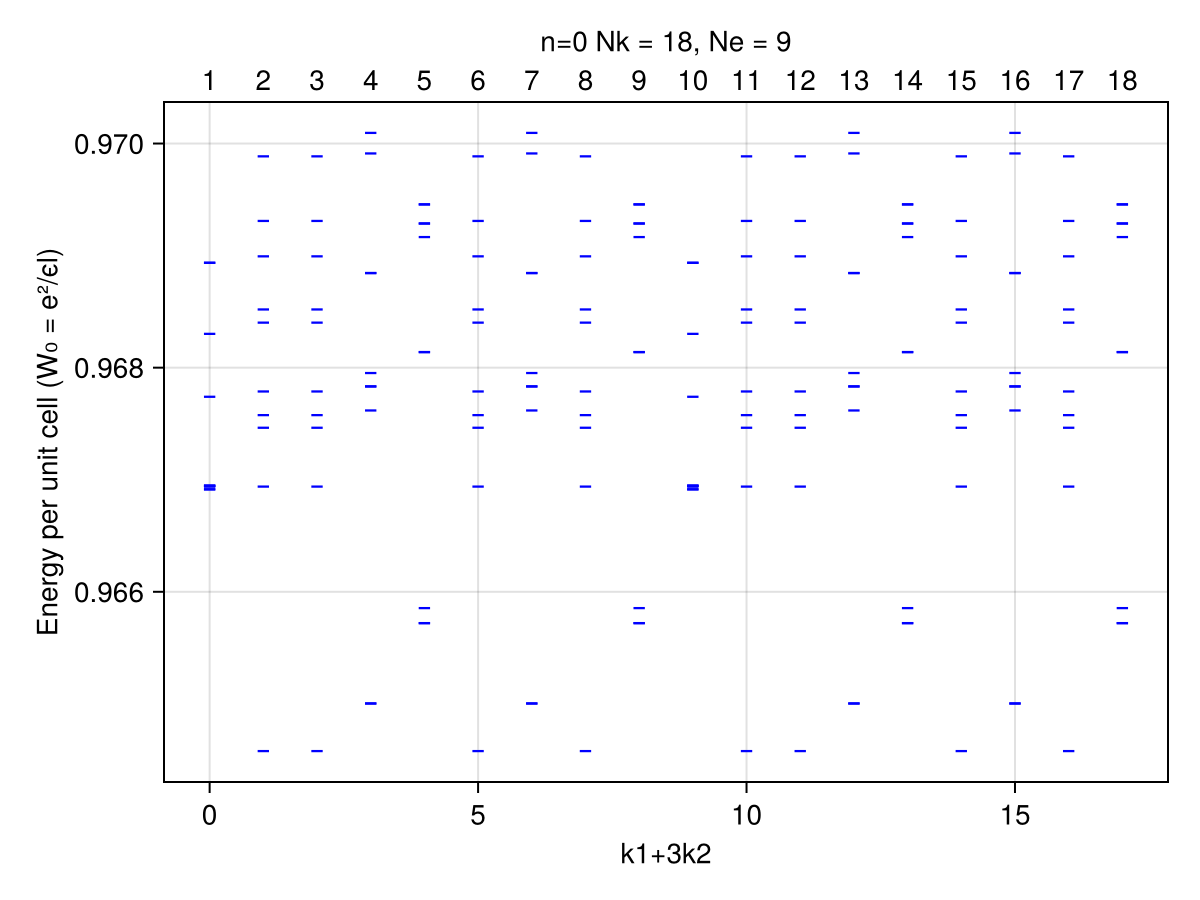

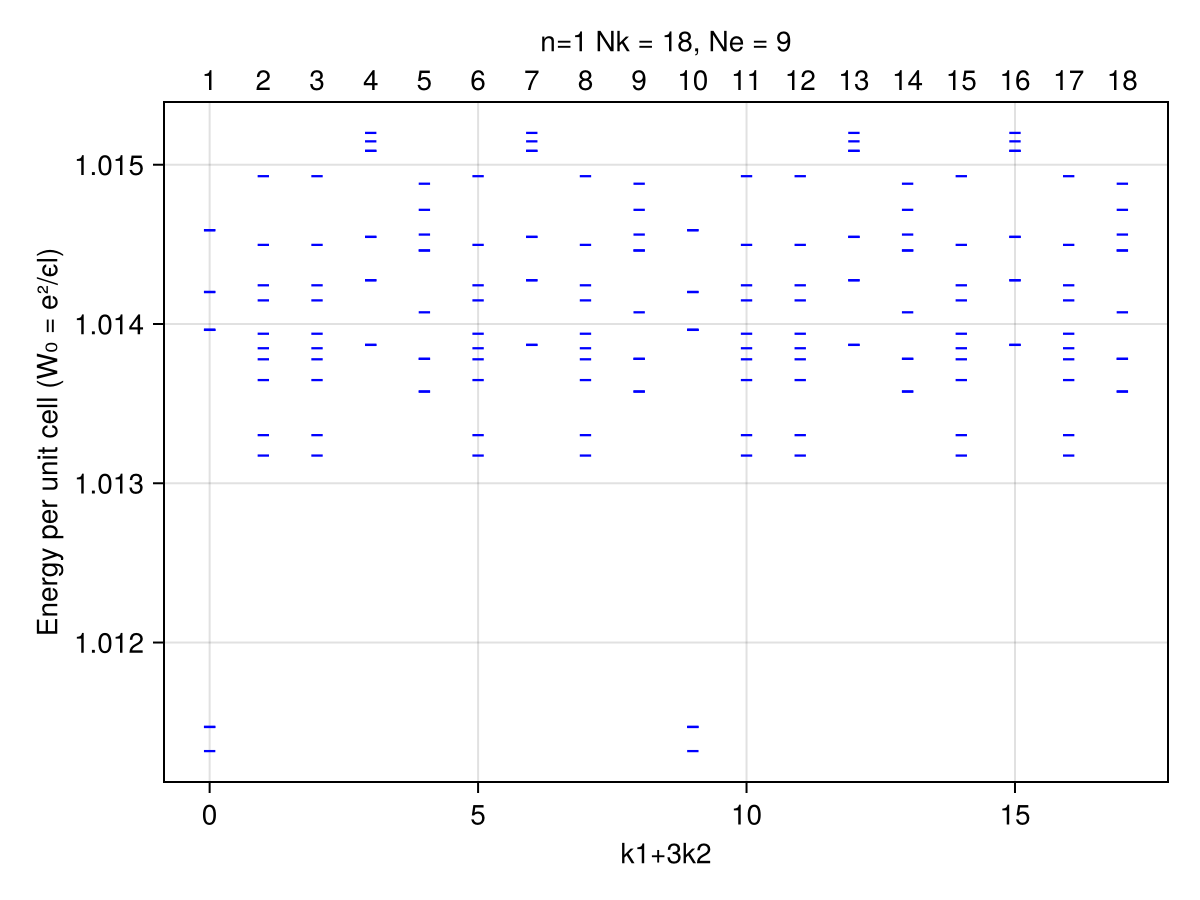

In [12]:
plot_ed_spectrum(energies0/Nk/LLT.W0, ss_k, Gk;
    title = "n=0 Nk = $Nk, Ne = $Ne",
    # ylims = (0.964, 0.968),
);
plot_ed_spectrum(energies1/Nk/LLT.W0, ss_k, Gk;
    title = "n=1 Nk = $Nk, Ne = $Ne",
    # ylims = (1.011, 1.012),
);

In [13]:
# check energies explicitly to see degeneracy.
sn = 11        # the subspace number to inspect (see the top of spectrum plot)
println("n=0   sn=$sn  total momentum: $(ss_k[sn]):")
energies0[sn]/Nk/LLT.W0

n=0   sn=11  total momentum: (1, 3):


10-element Vector{Float64}:
 0.9645785784467902
 0.966938615575159
 0.9674636464662214
 0.9675763379876998
 0.967787445420718
 0.96840167486636
 0.968519279836591
 0.9689931675334249
 0.9693090770320758
 0.969885468024049

In [14]:
# check energies explicitly to see degeneracy.
sn = 10        # the subspace number to inspect (see the top of spectrum plot)
println("n=1   sn=$sn  total momentum: $(ss_k[sn]):")
energies1[sn]/Nk/LLT.W0

n=1   sn=10  total momentum: (0, 3):


10-element Vector{Float64}:
 1.0113185330876735
 1.0114702531755229
 1.011470253175526
 1.013963166732426
 1.0139631667324267
 1.0139631667324287
 1.0142010277335773
 1.0142010277335822
 1.014589111217361
 1.0145891112173657

expectation values of m pseudopotentials

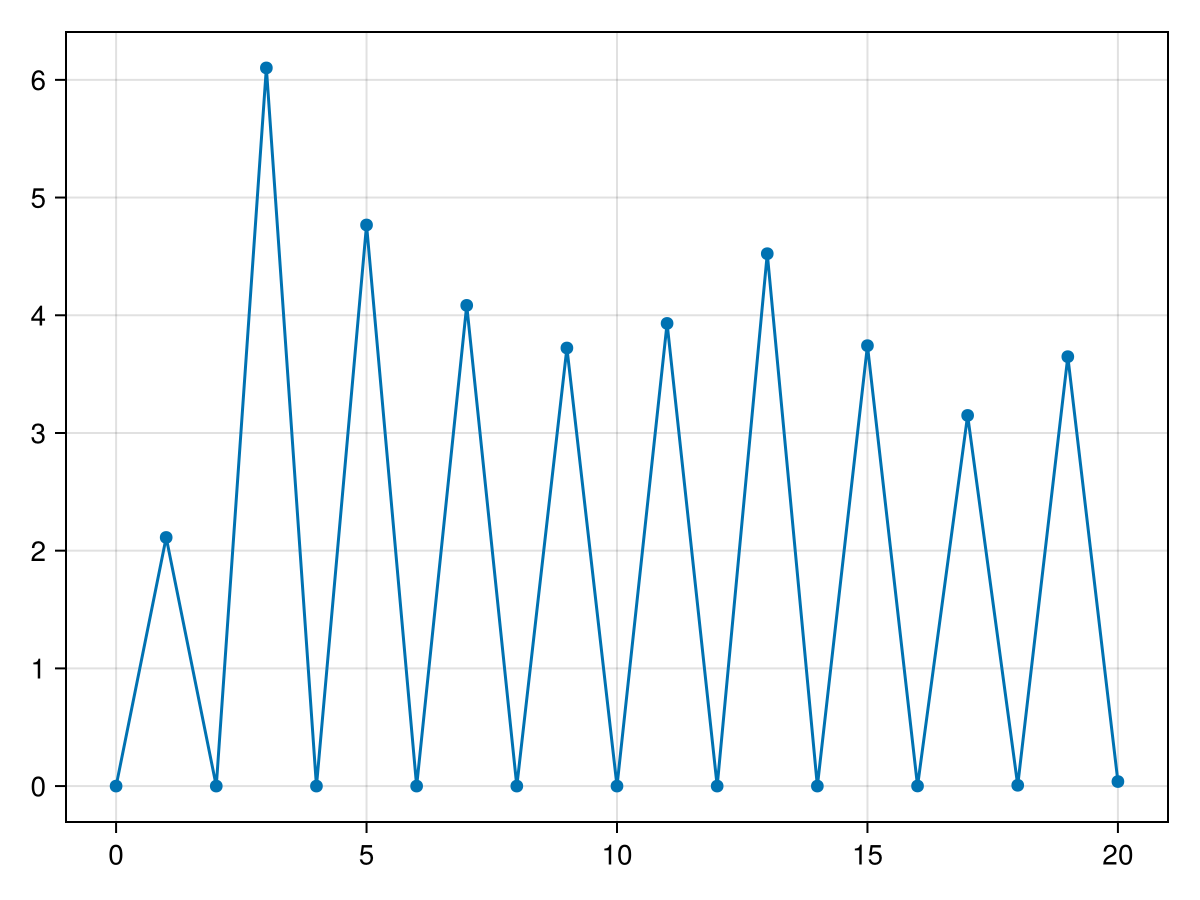

In [15]:
vec = vectors0[11][1]
E_m = [ED_bracket(vec, Hm0[i], vec) |> real 
    for i in eachindex(m_list)]
scatterlines(m_list, E_m)

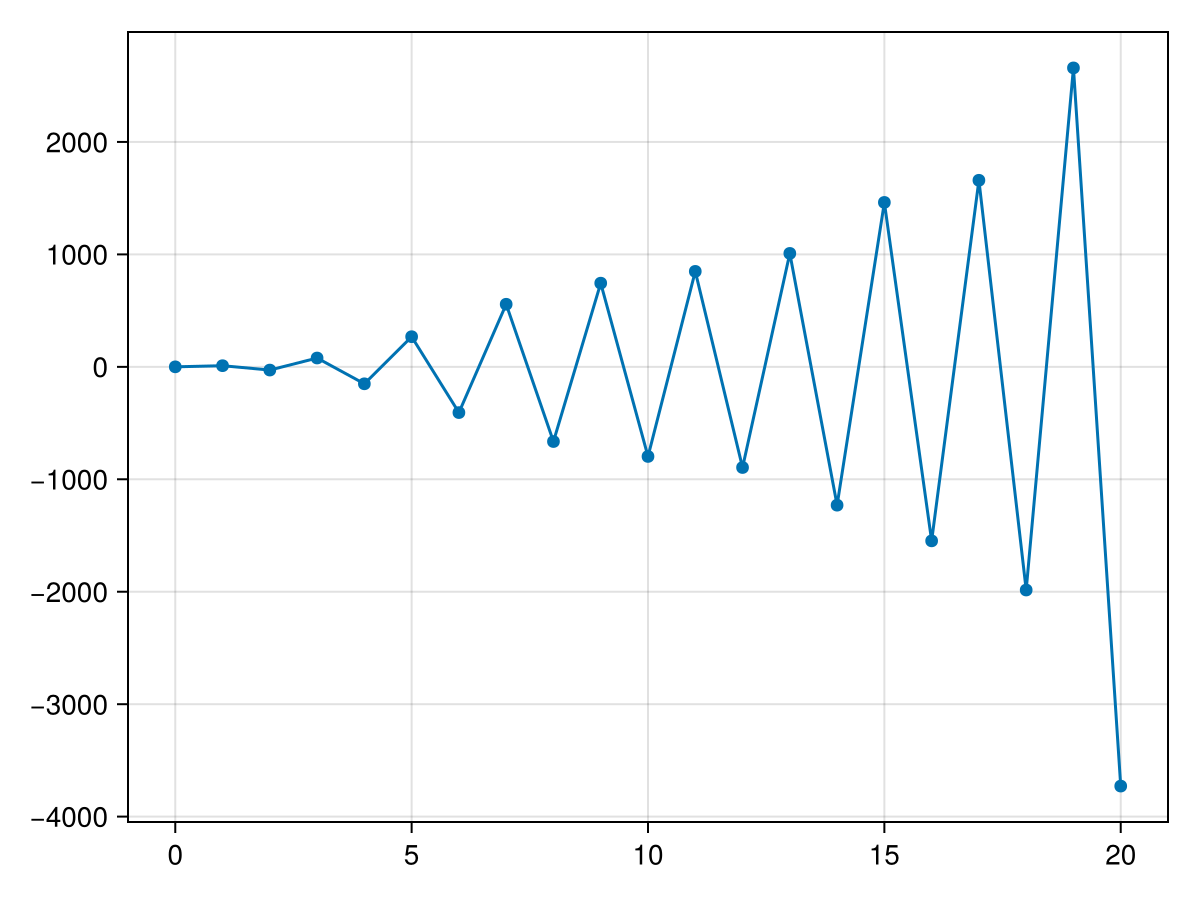

In [16]:
vec = vectors1[10][3]
E_m = [ED_bracket(vec, Hm1[i], vec) |> real 
    for i in eachindex(m_list)]
scatterlines(m_list, E_m)

Compute the many-body connection and the Wilson loop for many-body Chern number.

In [17]:
function manybody_overlap(para::EDPara, 
    ψ_f, ψ_i, k_f::Tuple{<:Real, <:Real}, k_i::Tuple{<:Real, <:Real})
    
    orbital_bc = orbital_overlap(para, k_f, k_i)
    return ED_step_inner_prod(ψ_f, ψ_i, orbital_bc)
end

manybody_overlap (generic function with 1 method)

In [18]:
# path for the Wilson loop integral on base manifold
# Landau level has uniform Berry curvature, so we compute Berry curvature of a small plaquate and then multiply plaquate number
N_kshift = 10  # number of shifts along each edge
path = Tuple{Rational, Rational}[(0//1, 0//1)]
push!(path, (1//N_kshift, 0//1))
push!(path, (1//N_kshift, 1//N_kshift))
push!(path, (0//1, 1//N_kshift))
push!(path, (0//1, 0//1))
path

5-element Vector{Tuple{Rational, Rational}}:
 (0, 0)
 (1//10, 0)
 (1//10, 1//10)
 (0, 1//10)
 (0, 0)

In [19]:
# n=0 CFL
sn = 11; vn_range = 1:1;
psi0 = similar(path, Vector{typeof(vectors0[sn][1])})
for i in eachindex(path)
    if i ∈ (1,5)
        psi0[i] = vectors0[sn][vn_range]
        continue
    end
    scat_list = ED_scatterlist_twobody(para0; kshift = path[i]);
    hmlt_local = MBOperator(scat_list; upper_hermitian = true)
    psi0[i] = EDsolve(subspaces[sn], hmlt_local; N = 6,
        showtime = false,
    )[2][vn_range]
end

WilsonLoopIntegral0 = Vector{Matrix{ComplexF64}}(undef, 4)
for i in eachindex(WilsonLoopIntegral0)
    WilsonLoopIntegral0[i] = manybody_overlap(para0, 
    psi0[i+1], psi0[i], path[i+1], path[i])
end
ManyBodyChernNumber0 = angle(det(prod(WilsonLoopIntegral0))) / (2π) * N_kshift^2
ManyBodyChernNumber0 /= length(vn_range)

0.4999999999999798

In [20]:
# n=1 Moore-Read
sn = 10; vn_range = 1:3;
psi1 = similar(path, Vector{typeof(vectors1[sn][1])})
for i in eachindex(path)
    if i ∈ (1,5)
        psi1[i] = vectors1[sn][vn_range]
        continue
    end
    scat_list = ED_scatterlist_twobody(para1; kshift = path[i]);
    hmlt_local = MBOperator(scat_list; upper_hermitian = true)
    psi1[i] = EDsolve(subspaces[sn], hmlt_local; N = 6,
        showtime = false,
    )[2][vn_range]
end

WilsonLoopIntegral1 = Vector{Matrix{ComplexF64}}(undef, 4)
for i in eachindex(WilsonLoopIntegral1)
    WilsonLoopIntegral1[i] = manybody_overlap(para1, 
    psi1[i+1], psi1[i], path[i+1], path[i])
end
ManyBodyChernNumber1 = angle(det(prod(WilsonLoopIntegral1))) / (2π) * N_kshift^2
ManyBodyChernNumber1 /= length(vn_range)

0.49999999999997874